In [1]:
pip install --upgrade google-api-python-client

In [2]:
from googleapiclient.discovery import build
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Channel Ids:
channel_id = "UCQVWm3oqqa6cfQDC2JivNrQ"  # HKUST Business School Channel
channel_ids = ["UC8gVLOsrUB1273QKBXN43-w", # School of Science HKUST
               "UCQVWm3oqqa6cfQDC2JivNrQ", # HKUST Business School
               "UCoGEOXH4p5bfVdiCbJieExg", # HKUST MBA
               "UCERIUAWf06E4zRkfwXco1eg", # HKUST Engineering
               "UCHj5zaHbi-YY3snMG_l-mEw", # HKUST SHSS Undergraduate
               "UCMSRoB8btmnpgQKqoiPfsOg", # HKUST IPO
               "UCw0YnuHru0f-crxpJ0L6WEw", # HKUST Sustainability
               "UCHmevvdA40MjuOocPnErTlA", # HKUST Business School UG Admission
               "UC7M0G_Khi9YQyjd_tZs03WA", # Stem HKUST
               "UCdPKqb9MlZ4OKMDKDYxzymQ", # HKUST - Institute for the Environment
               "UCLqJXC7LGH1NFme8yNodkFA", # IEDA HKUST
               "UCwuSxm_TlgRGTGWrqmDhfyw", # Global Business
               "UCREyb1oGFA-wCjnzhEHostQ", # HKUST School of Science - Undergraduate Admissions
               "UCN2zi5yDrHP6IrVkppC3gfw", # Kellogg-HKUST Executive MBA Program
               "UCJsA4wYUzorqpdzZb-miSHg", # The Business Students' Union
               "UC8-YdPrfYNlL6TsWs9Md6Mg", # HKUST Undergraduate Admissions
               "UCm-K0TFf-0m6lXjgwWJAZsA", # HKUST Center for the Arts
               "UCSalbWQqAFNWMj31Z1vDuCA", # HKUST Institute for Emerging Market Studies
               "UCEdTCnlB6_BrqjY29RPturQ", # HKUST - Postgraduate Studies
              ]

In [ ]:
api_key = ""  # Userkey for extracting data from YouTube API # delete here

# Top 5 universities YouTube Channel Analysis

channel_id = "UCeG0cjZClabYTnYZldpCNwQ"

channel_ids = ["UCdRnXk2yE-4olVkgz0tECvw", # HKUST Official YouTube
               "UCvZ4seZaqaO_A_WPfL-d9WQ", # HKU Official YouTube
               "UCeG0cjZClabYTnYZldpCNwQ", # CUHK Official YouTube
               "UCkio4asleKcQVRVEM8RnXlQ", # PolyTechnic University Official YouTube
               "UC1OVYBbIxEFAzm_Hc4nvG9w", # City University Official YouTube
               
              ]

youtube = build("youtube", "v3", developerKey=api_key)

## Function to get channel statistics

In [4]:
# Function was used to extract specific channel stats from YouTube

def get_channel_stats(youtube, channel_ids):
    all_data = []
    request = youtube.channels().list(
                part="snippet, contentDetails,statistics",
                id=",".join(channel_ids))
    response = request.execute()
    
    for i in range(len(response["items"])):
        data = dict(channel_name = response["items"][i]["snippet"]["title"],
                    subscribers = response["items"][i]["statistics"]["subscriberCount"],
                    views = response["items"][i]["statistics"]["viewCount"],
                    total_videos = response["items"][i]["statistics"]["videoCount"],
                    playlist_id = response["items"][i]["contentDetails"]["relatedPlaylists"]["uploads"]
                   )
        all_data.append(data)
    
    return all_data

In [5]:
channel_statistics = get_channel_stats(youtube, channel_ids)

In [6]:
channel_data = pd.DataFrame(channel_statistics)
channel_data

,channel_name,subscribers,views,total_videos,playlist_id
0,CityUHongKong,3230,4242092,416,UU1OVYBbIxEFAzm_Hc4nvG9w
1,The Hong Kong Polytechnic University,7860,3372033,658,UUkio4asleKcQVRVEM8RnXlQ
2,The University of Hong Kong,11500,2313545,694,UUvZ4seZaqaO_A_WPfL-d9WQ
3,CUHK Channel,12400,2425747,538,UUeG0cjZClabYTnYZldpCNwQ
4,HKUST,4490,712156,421,UUdRnXk2yE-4olVkgz0tECvw


In [7]:
#Transforming data for processing

channel_data["subscribers"] = pd.to_numeric(channel_data["subscribers"])
channel_data["views"] = pd.to_numeric(channel_data["views"])
channel_data["total_videos"] = pd.to_numeric(channel_data["total_videos"])
channel_data.dtypes

channel_name    object
subscribers      int64
views            int64
total_videos     int64
playlist_id     object
dtype: object

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'CityUHongKong'),
  Text(1, 0, 'The Hong Kong Polytechnic University'),
  Text(2, 0, 'The University of Hong Kong'),
  Text(3, 0, 'CUHK Channel'),
  Text(4, 0, 'HKUST')])

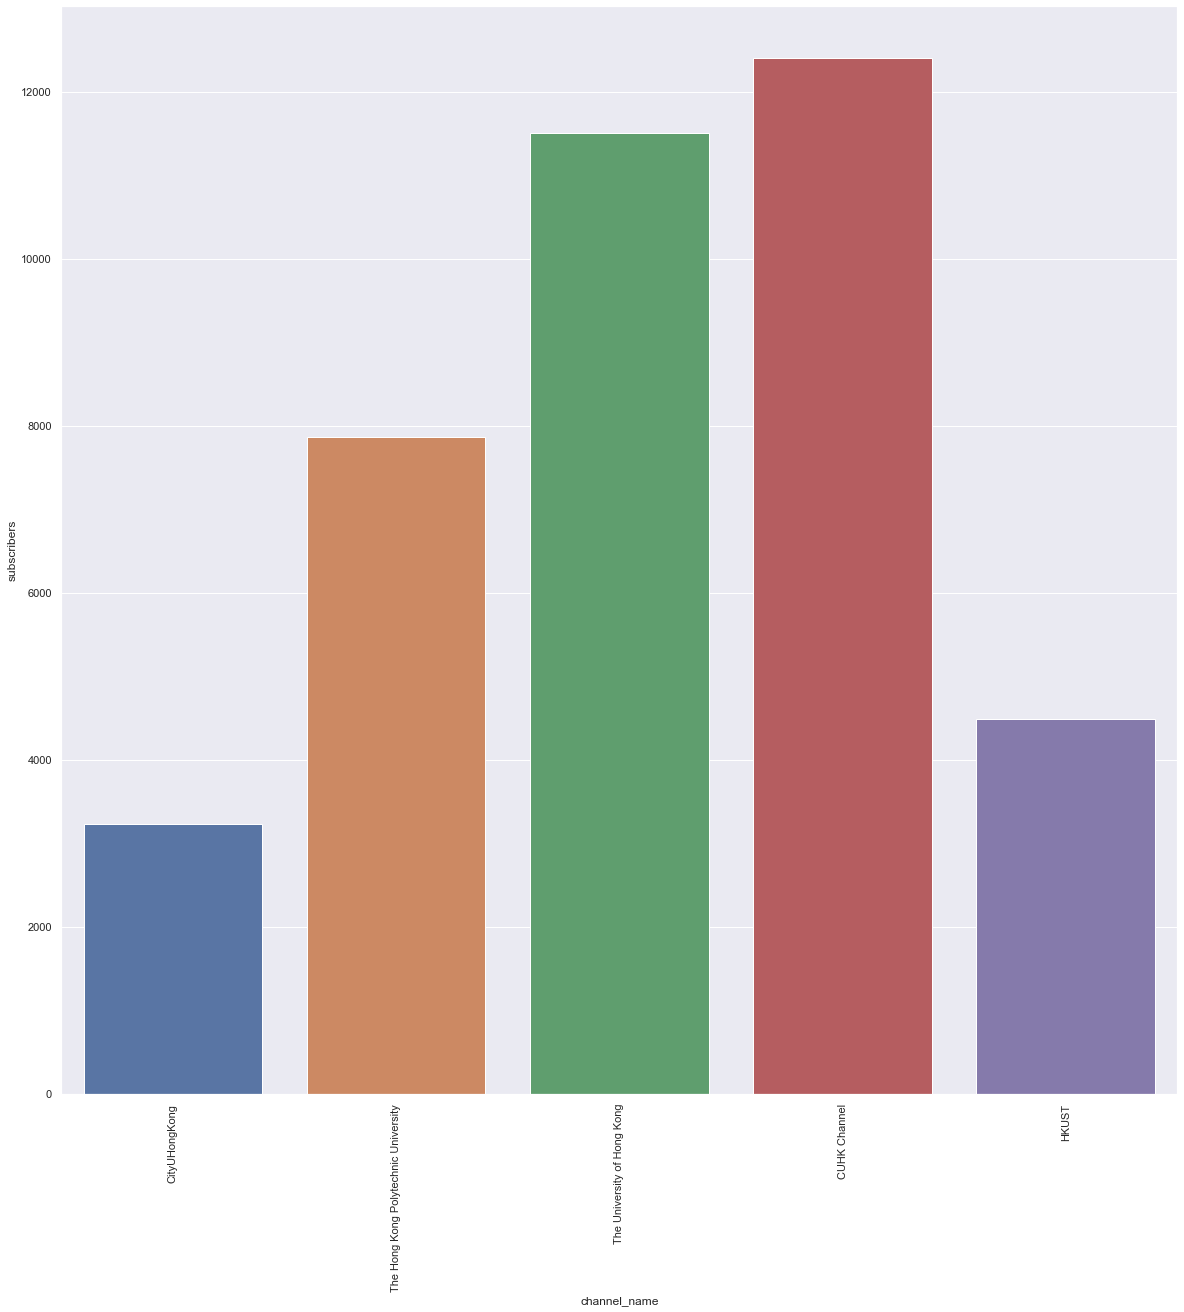

In [8]:
#Test chart to visualise select data which was extracted

sns.set(rc={"figure.figsize":(20,20)})
ax = sns.barplot(x="channel_name", y="subscribers", data=channel_data) # Visualisation of subscribers per channel
plt.xticks(rotation=90)

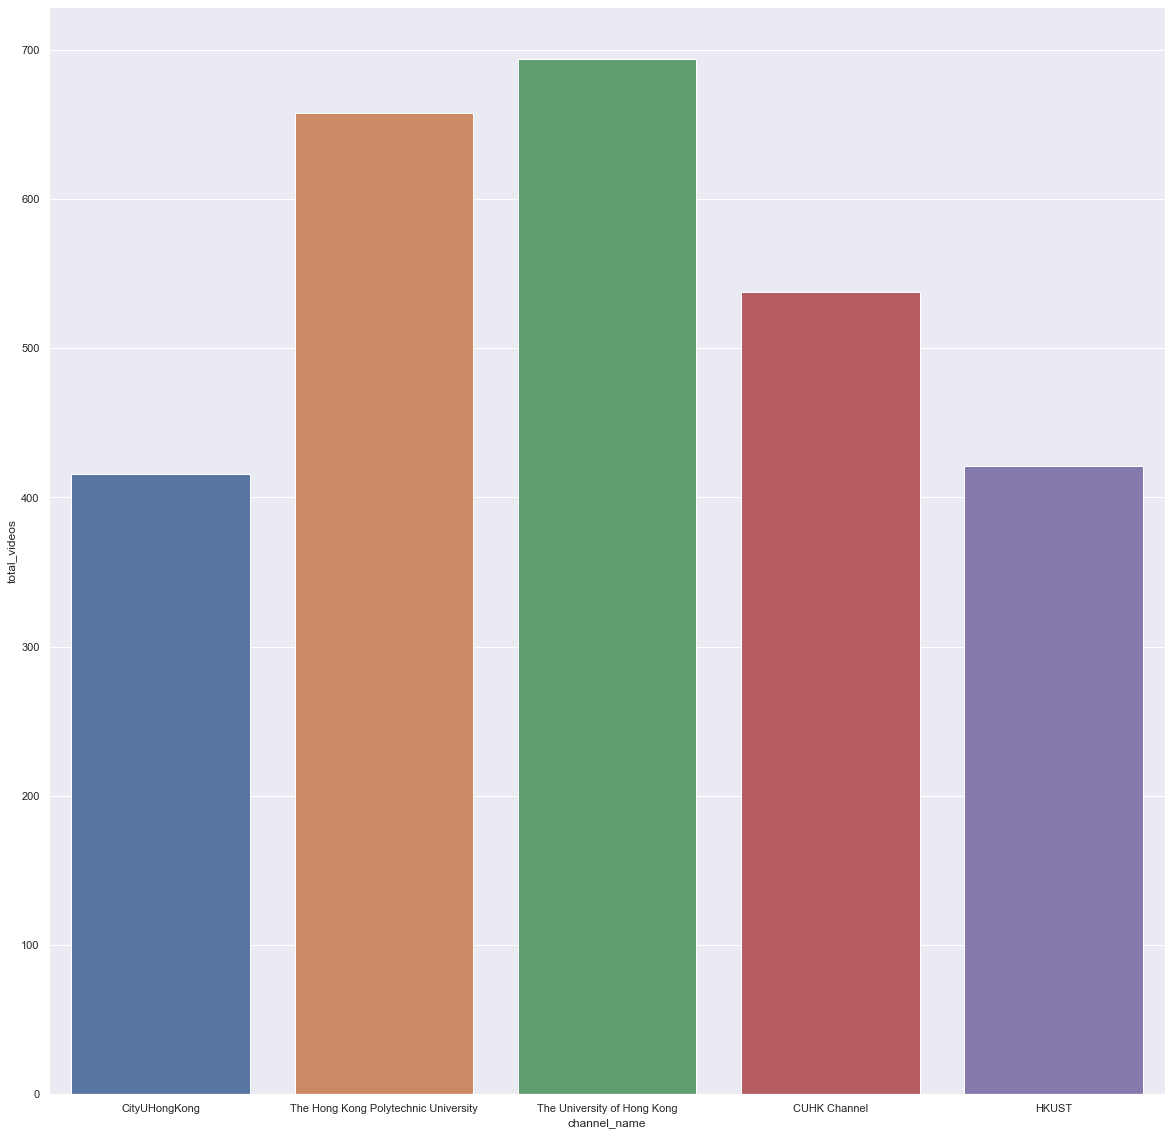

In [9]:
sns.set(rc={"figure.figsize":(20,20)})
ax = sns.barplot(x="channel_name", y="total_videos", data=channel_data)

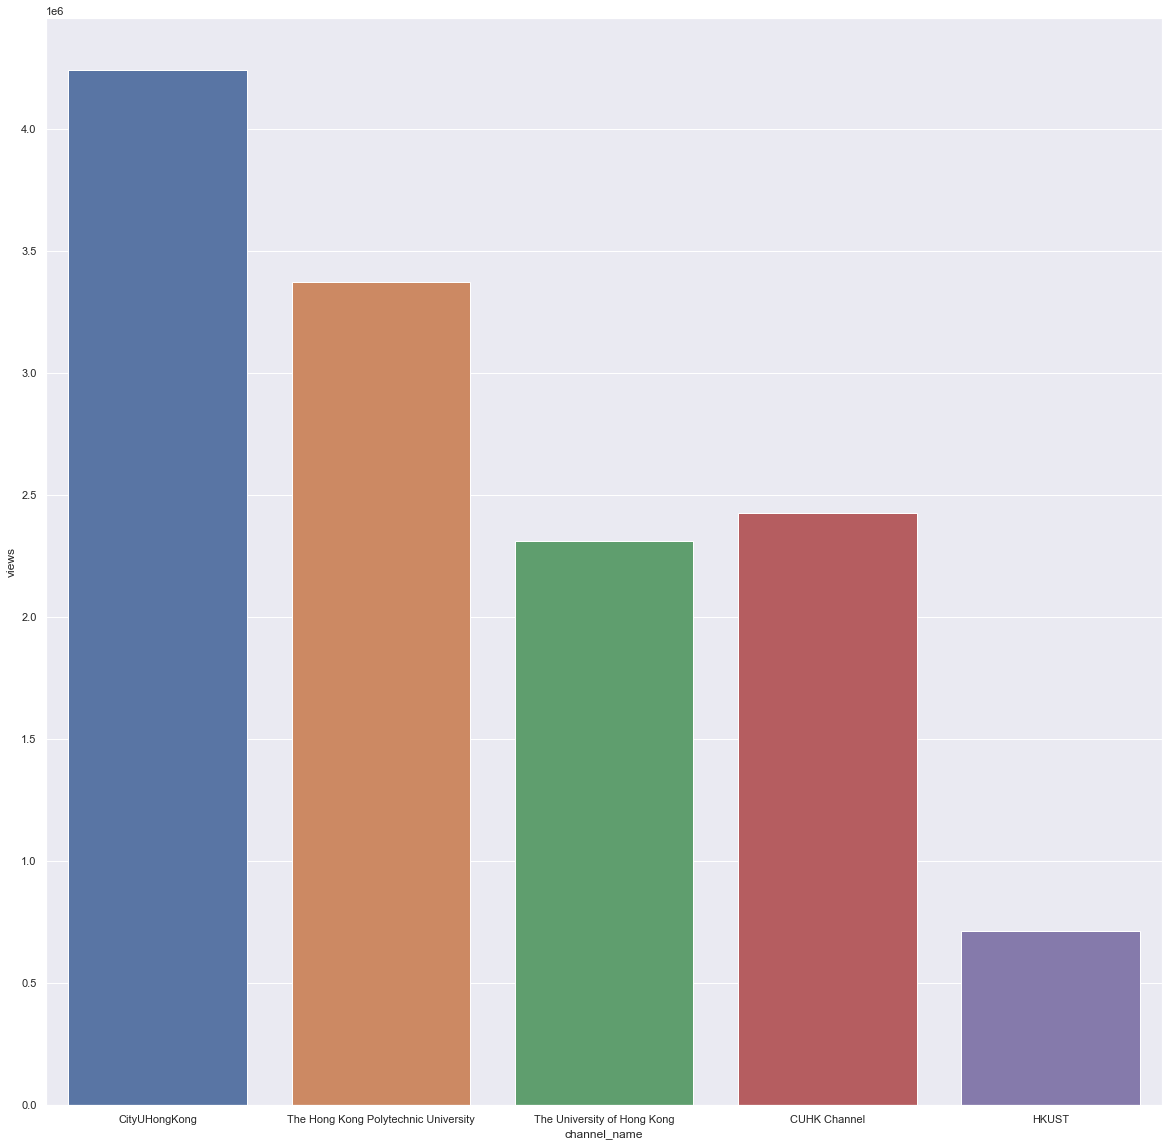

In [10]:
sns.set(rc={"figure.figsize":(20,20)})
ax = sns.barplot(x="channel_name", y="views", data=channel_data)

## Fetching Video Ids

In [11]:
channel_data

,channel_name,subscribers,views,total_videos,playlist_id
0,CityUHongKong,3230,4242092,416,UU1OVYBbIxEFAzm_Hc4nvG9w
1,The Hong Kong Polytechnic University,7860,3372033,658,UUkio4asleKcQVRVEM8RnXlQ
2,The University of Hong Kong,11500,2313545,694,UUvZ4seZaqaO_A_WPfL-d9WQ
3,CUHK Channel,12400,2425747,538,UUeG0cjZClabYTnYZldpCNwQ
4,HKUST,4490,712156,421,UUdRnXk2yE-4olVkgz0tECvw


In [12]:
#Extract all the playlist id of the videos within the channels

playlist_id_HKUST = channel_data.loc[channel_data["channel_name"]=="HKUST", "playlist_id"].iloc[0]
playlist_id_CUHK = channel_data.loc[channel_data["channel_name"]=="CUHK Channel", "playlist_id"].iloc[0]
playlist_id_HKU = channel_data.loc[channel_data["channel_name"]=="The University of Hong Kong", "playlist_id"].iloc[0]
playlist_id_CityU = channel_data.loc[channel_data["channel_name"]=="CityUHongKong", "playlist_id"].iloc[0]
playlist_id_PU = channel_data.loc[channel_data["channel_name"]=="The Hong Kong Polytechnic University", "playlist_id"].iloc[0]

In [13]:
#Function to extract number of videos within each channel

def get_video_ids(youtube,playlist_id):
    
    request = youtube.playlistItems().list(part="contentDetails", playlistId = playlist_id, maxResults = 50)
    
    response = request.execute()
    
    video_ids = []
    
    for i in range(len(response["items"])):
        video_ids.append(response["items"][i]["contentDetails"]["videoId"])
    
    next_page_token = response.get("nextPageToken")
    more_pages = True
    
    while more_pages:
        if next_page_token is None:
            more_pages = False
        else:
            request = youtube.playlistItems().list(part="contentDetails", playlistId = playlist_id, maxResults = 50, pageToken = next_page_token)
            response = request.execute()
            
            for i in range(len(response["items"])):
                video_ids.append(response["items"][i]["contentDetails"]["videoId"])
                
            next_page_token = response.get("nextPageToken")
                
    return video_ids

In [14]:
HKUST_video_ids = get_video_ids(youtube,playlist_id_HKUST)
CUHK_video_ids = get_video_ids(youtube,playlist_id_CUHK)
HKU_video_ids = get_video_ids(youtube,playlist_id_HKU)
CityU_video_ids = get_video_ids(youtube,playlist_id_CityU)
PU_video_ids = get_video_ids(youtube,playlist_id_PU)

print("HKUST: ", len(HKUST_video_ids))
print("CUHK: ", len(CUHK_video_ids))
print("HKU: ", len(HKU_video_ids))
print("CityU: ", len(CityU_video_ids))
print("PU: ", len(PU_video_ids))

HKUST:  421
CUHK:  538
HKU:  694
CityU:  416
PU:  659


In [15]:
len(HKUST_video_ids+CUHK_video_ids+HKU_video_ids+CityU_video_ids+PU_video_ids)

2728

## Function to extract video details

In [16]:
#Function to find out what data are available

def get_video_details(youtube, video_ids):
        request = youtube.videos().list(part="snippet, contentDetails, topicDetails, statistics", 
                                        id=",".join(video_ids[:5]))
        response = request.execute()
        
        return response

In [17]:
get_video_details(youtube, PU_video_ids)

{'kind': 'youtube#videoListResponse',
 'etag': 'QVsEfurq8yJ6HQ7LwBIF1cYLA8M',
 'items': [{'kind': 'youtube#video',
   'etag': '258hzQTFJ7r58BpAVNU4Mu755zM',
   'id': 'S_yTf4GvHa8',
   'snippet': {'publishedAt': '2022-10-13T04:06:43Z',
    'channelId': 'UCkio4asleKcQVRVEM8RnXlQ',
    'title': 'PolyU Science “Our Alumni, Our Pride” – Dr Edmond Ho',
    'description': '理大理學院 “Our Alumni, Our Pride” – 何健民博士\n\n理大培育了逾40萬名校友，桃李滿門。他們投身各行各業，當中不乏各專業與工商界領袖及翹楚，是推動香港發展的强大力量。為慶祝理大85周年校慶，理學院特別推出“Our Alumni Our Pride” 影片系列，邀請了數名出色的校友分享他們如何尋索個人路向和為所屬行業及社會作出貢獻。\n\n於應用生物及化學科技學系取得博士學位的何健民博士將率先分享他研發出納米抗擦墨，以打擊不法商人竄改有效食用日期的經歷。 這種「抗擦墨」不單有效保障食品安全，更為企業帶來了可觀的經濟效益。\n\nPolyU has nurtured more than 400,000 alumni to help forge the development of Hong Kong. They have been distinguished leaders in all sectors of society, including in various professions, industries and businesses. In celebration of PolyU’s 85th Anniversary, the Faculty of Science proudly presents a new video series “Our Alumni, Our Pride”, featuring

In [18]:
#Function for converting YouTube's standard time format into numerical time format for processing

import re

def yt_time(duration):

    ISO_8601 = re.compile(
        'P'   # designates a period
        '(?:(?P<years>\d+)Y)?'   # years
        '(?:(?P<months>\d+)M)?'  # months
        '(?:(?P<weeks>\d+)W)?'   # weeks
        '(?:(?P<days>\d+)D)?'    # days
        '(?:T' # time part must begin with a T
        '(?:(?P<hours>\d+)H)?'   # hours
        '(?:(?P<minutes>\d+)M)?' # minutes
        '(?:(?P<seconds>\d+)S)?' # seconds
        ')?')   # end of time part
    # Convert regex matches into a short list of time units
    units = list(ISO_8601.match(duration).groups()[-3:])
    # Put list in ascending order & remove 'None' types
    units = list(reversed([int(x) if x != None else 0 for x in units]))
    # Do the maths
    return sum([x*60**units.index(x) for x in units])

In [19]:
#Function for extracting video specific data 

def get_video_details(youtube, video_ids):

    all_video_stats = []
    
    for i in range(0, len(video_ids), 50):
                   
        request = youtube.videos().list(part="snippet, contentDetails, statistics", 
                                        id=",".join(video_ids[i:i+50]))
        response = request.execute()
                   
        for video in response["items"]:         
                video_stats = dict(
                    Channel_name = video["snippet"]["channelTitle"],
                    Title = video["snippet"]["title"],
                    Description = video["snippet"]["description"],
                    Category = video["snippet"]["categoryId"],
                    Published_date = video["snippet"]["publishedAt"],
                    Duration = yt_time(video["contentDetails"]["duration"]),
                    Tags = video["snippet"].get("tags",None),
                    Views = video["statistics"]["viewCount"],
                    Likes = video["statistics"].get("likeCount",0),
                    Favourites = video["statistics"]["favoriteCount"],
                    Comments = video["statistics"].get("commentCount",0))
                all_video_stats.append(video_stats)
                   
    
    return all_video_stats

In [20]:
#Extracting latest categorisation of videos available in YouTube

    # calling the videoCategory.list method
    # to retrieve youtube video categories result
    video_category = youtube.videoCategories(
       ).list(part ='snippet', regionCode ='IN').execute()
      
    # extracting the results
    # from video_category response
    results = video_category.get("items", [])
  
    # empty list to store video category metadata
    videos_categories = []
      
    # extracting required info
    # from each result object
    for result in results:
          
        # video_categories result object
        videos_categories.append((result["id"],
                   result["snippet"]["title"]))

videos_categories

[('1', 'Film & Animation'),
 ('2', 'Autos & Vehicles'),
 ('10', 'Music'),
 ('15', 'Pets & Animals'),
 ('17', 'Sports'),
 ('18', 'Short Movies'),
 ('19', 'Travel & Events'),
 ('20', 'Gaming'),
 ('21', 'Videoblogging'),
 ('22', 'People & Blogs'),
 ('23', 'Comedy'),
 ('24', 'Entertainment'),
 ('25', 'News & Politics'),
 ('26', 'Howto & Style'),
 ('27', 'Education'),
 ('28', 'Science & Technology'),
 ('30', 'Movies'),
 ('31', 'Anime/Animation'),
 ('32', 'Action/Adventure'),
 ('33', 'Classics'),
 ('34', 'Comedy'),
 ('35', 'Documentary'),
 ('36', 'Drama'),
 ('37', 'Family'),
 ('38', 'Foreign'),
 ('39', 'Horror'),
 ('40', 'Sci-Fi/Fantasy'),
 ('41', 'Thriller'),
 ('42', 'Shorts'),
 ('43', 'Shows'),
 ('44', 'Trailers')]

In [21]:
video_categories = pd.DataFrame(videos_categories)
video_categories.rename(columns = {'0':'VC_id'}, inplace = True)
video_categories.rename(columns = {'1':'Genre'}, inplace = True)
video_categories

,0,1
0,1,Film & Animation
1,2,Autos & Vehicles
2,10,Music
3,15,Pets & Animals
4,17,Sports
5,18,Short Movies
6,19,Travel & Events
7,20,Gaming
8,21,Videoblogging
9,22,People & Blogs


In [22]:
# Creating a mapping list to convert numberical figures into video categories in string format

vc_map = {1:"Film & Animation", 2:"Auto & Vehicles",10:"Music",15:"Pets & Animals", 17:"Sports",18:"Short Movies",19:"Travel & Events", 20:"Gaming",21:"Videoblogging", 22:"People & Blogs", 23:"Comedy",24:"Entertainment", 25:"News & Politics",26:"Howto & Style", 27:"Education", 28:"Sceince & Technology", 30:"Movies", 31:"Anime/Animation", 32:"Action/Adventure", 33:"Classics",34:"Comedy", 35:"Documentary", 36:"Drama", 37:"Family", 38:"Foreign", 39:"Horror",40:"Sci-Fi/Fantasy", 41:"Thriller",42:"Shorts",43:"Shows",44:"Trailers"}

In [23]:
CUHK_video_details = get_video_details(youtube, CUHK_video_ids)

In [24]:
CUHK_video_details

[{'Channel_name': 'CUHK Channel',
  'Title': '點解你鍾意中大？Why do you like CUHK? Alumni Simon x Rainbow',
  'Description': '崇基學院校友Simon同Rainbow在中大校園相遇、相知、相愛，二人帶住愛情結晶品重回母校，佢地最鍾意中大嘅乜咩？立即睇片啦！\n\n#香港中文大學 #中大 #中大本科入學資訊日2022 #thechineseuniversityofhongkong #cuhk #cuhkinfoday2022\n\n聯絡我們 Connect with Us: https://linktr.ee/CUHK',
  'Category': '27',
  'Published_date': '2022-10-14T09:58:10Z',
  'Duration': 91,
  'Tags': ['CUHK', '中大', 'video'],
  'Views': '232',
  'Likes': '5',
  'Favourites': '0',
  'Comments': 0},
 {'Channel_name': 'CUHK Channel',
  'Title': '點解你鍾意中大？晨興書院同學仔 Why do you like CUHK? Morningside College students',
  'Description': '一班來自五湖四海嘅晨興書院同學仔，離鄉別井來到中大讀書，個個都好享受校園生活，而每個人最鍾意中大嘅…？睇片聽佢地講！\n\n#香港中文大學 #中大 #中大本科入學資訊日2022 #thechineseuniversityofhongkong #cuhk #cuhkinfoday2022\n\n聯絡我們 Connect with Us: https://linktr.ee/CUHK',
  'Category': '27',
  'Published_date': '2022-10-14T09:56:51Z',
  'Duration': 124,
  'Tags': ['CUHK', '中大', 'video'],
  'Views': '263',
  'Likes': '9',
  'Favourite

In [25]:
CityU_video_details = get_video_details(youtube, CityU_video_ids)
HKU_video_details = get_video_details(youtube, HKU_video_ids)
HKUST_video_details = get_video_details(youtube, HKUST_video_ids)
PU_video_details = get_video_details(youtube, PU_video_ids)

In [26]:
HKUST_video_data = pd.DataFrame(HKUST_video_details)
CUHK_video_data = pd.DataFrame(CUHK_video_details)
HKU_video_data = pd.DataFrame(HKU_video_details)
CityU_video_data = pd.DataFrame(CityU_video_details)
PU_video_data = pd.DataFrame(PU_video_details)

In [27]:
frames = [HKUST_video_data,HKU_video_data,CUHK_video_data,CityU_video_data,PU_video_data]
all_video_data = pd.concat(frames)
all_video_data.shape

(2728, 11)

In [28]:
all_video_data

,Channel_name,Title,Description,Category,Published_date,Duration,Tags,Views,Likes,Favourites,Comments
0,HKUST,HKUST Named Professorships | Otto Poon Profess...,[ #HKUST Named Professorships | Otto Poon Prof...,27,2022-10-13T16:00:21Z,135,[HKUST],56,0,0,0
1,HKUST,HKUST Named Professorships | Padma Harilela As...,[ #HKUST Named Professorships | Padma Harilela...,27,2022-10-11T16:00:17Z,130,[HKUST],69,1,0,0
2,HKUST,HKUST Entrepreneurship Fund (“E-Fund”) - Trans...,[ Innovation & Entrepreneurship | Transferring...,27,2022-10-11T03:01:10Z,294,[HKUST],64,1,0,0
3,HKUST,HKUST Named Professorships | Hari Harilela Ass...,[ #HKUST Named Professorships | Hari Harilela ...,27,2022-10-09T16:00:27Z,130,[HKUST],107,3,0,0
4,HKUST,HKUST Named Professorships | Kerry Holdings Pr...,[ #HKUST Named Professorships | Kerry Holdings...,27,2022-10-06T16:00:36Z,135,[HKUST],111,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...
654,The Hong Kong Polytechnic University,"Sharing of PolyU Outstanding Students (FAST, F...","In this video, outstanding students from Facul...",27,2008-09-26T07:47:30Z,378,"[PolyU, engineering, textiles, social, science...",2148,0,0,0
655,The Hong Kong Polytechnic University,"Sharing of PolyU Outstanding Students (FB, FCL...","In this video, outstanding students from Facu...",27,2008-09-26T07:41:30Z,324,"[PolyU, outstanding, student, business, constr...",1926,0,0,0
656,The Hong Kong Polytechnic University,PolyU Engineering Summer Camp 2008,PolyU Engineering Summer Camp 2008: Tour with ...,27,2008-09-25T12:59:19Z,635,"[PolyU, Engineering, summer, camp, fun, educat...",1066,0,0,0
657,The Hong Kong Polytechnic University,PolyU Alumni Homecoming Carnival 2008,PolyU Alumni Homecoming Carnival was successfu...,27,2008-08-28T03:16:56Z,461,"[PolyU, alumni, family, fun, carnival, homecom...",284,0,0,0


In [29]:
#HKUST data processing

HKUST_video_data["Published_date"] = pd.to_datetime(HKUST_video_data["Published_date"]).dt.date
HKUST_video_data["Duration"] = pd.to_numeric(HKUST_video_data["Duration"])
HKUST_video_data["Category"] = pd.to_numeric(HKUST_video_data["Category"])
HKUST_video_data["Views"] = pd.to_numeric(HKUST_video_data["Views"])
HKUST_video_data["Likes"] = pd.to_numeric(HKUST_video_data["Likes"])
HKUST_video_data["Favourites"] = pd.to_numeric(HKUST_video_data["Favourites"])
HKUST_video_data["Comments"] = pd.to_numeric(HKUST_video_data["Comments"])

#HKU data processing

HKU_video_data["Published_date"] = pd.to_datetime(HKU_video_data["Published_date"]).dt.date
HKU_video_data["Duration"] = pd.to_numeric(HKU_video_data["Duration"])
HKU_video_data["Category"] = pd.to_numeric(HKU_video_data["Category"])
HKU_video_data["Views"] = pd.to_numeric(HKU_video_data["Views"])
HKU_video_data["Likes"] = pd.to_numeric(HKU_video_data["Likes"])
HKU_video_data["Favourites"] = pd.to_numeric(HKU_video_data["Favourites"])
HKU_video_data["Comments"] = pd.to_numeric(HKU_video_data["Comments"])

#CUHK data processing

CUHK_video_data["Published_date"] = pd.to_datetime(CUHK_video_data["Published_date"]).dt.date
CUHK_video_data["Duration"] = pd.to_numeric(CUHK_video_data["Duration"])
CUHK_video_data["Category"] = pd.to_numeric(CUHK_video_data["Category"])
CUHK_video_data["Views"] = pd.to_numeric(CUHK_video_data["Views"])
CUHK_video_data["Likes"] = pd.to_numeric(CUHK_video_data["Likes"])
CUHK_video_data["Favourites"] = pd.to_numeric(CUHK_video_data["Favourites"])
CUHK_video_data["Comments"] = pd.to_numeric(CUHK_video_data["Comments"])

#City U data processing

CityU_video_data["Published_date"] = pd.to_datetime(CityU_video_data["Published_date"]).dt.date
CityU_video_data["Duration"] = pd.to_numeric(CityU_video_data["Duration"])
CityU_video_data["Category"] = pd.to_numeric(CityU_video_data["Category"])
CityU_video_data["Views"] = pd.to_numeric(CityU_video_data["Views"])
CityU_video_data["Likes"] = pd.to_numeric(CityU_video_data["Likes"])
CityU_video_data["Favourites"] = pd.to_numeric(CityU_video_data["Favourites"])
CityU_video_data["Comments"] = pd.to_numeric(CityU_video_data["Comments"])

#Poly U data processing

PU_video_data["Published_date"] = pd.to_datetime(PU_video_data["Published_date"]).dt.date
PU_video_data["Duration"] = pd.to_numeric(PU_video_data["Duration"])
PU_video_data["Category"] = pd.to_numeric(PU_video_data["Category"])
PU_video_data["Views"] = pd.to_numeric(PU_video_data["Views"])
PU_video_data["Likes"] = pd.to_numeric(PU_video_data["Likes"])
PU_video_data["Favourites"] = pd.to_numeric(PU_video_data["Favourites"])
PU_video_data["Comments"] = pd.to_numeric(PU_video_data["Comments"])

#All Uni daata processing

all_video_data["Published_date"] = pd.to_datetime(all_video_data["Published_date"]).dt.date
all_video_data["Duration"] = pd.to_numeric(all_video_data["Duration"])
all_video_data["Category"] = pd.to_numeric(all_video_data["Category"])
all_video_data["Views"] = pd.to_numeric(all_video_data["Views"])
all_video_data["Likes"] = pd.to_numeric(all_video_data["Likes"])
all_video_data["Favourites"] = pd.to_numeric(all_video_data["Favourites"])
all_video_data["Comments"] = pd.to_numeric(all_video_data["Comments"])

In [30]:
all_video_data

,Channel_name,Title,Description,Category,Published_date,Duration,Tags,Views,Likes,Favourites,Comments
0,HKUST,HKUST Named Professorships | Otto Poon Profess...,[ #HKUST Named Professorships | Otto Poon Prof...,27,2022-10-13,135,[HKUST],56,0,0,0
1,HKUST,HKUST Named Professorships | Padma Harilela As...,[ #HKUST Named Professorships | Padma Harilela...,27,2022-10-11,130,[HKUST],69,1,0,0
2,HKUST,HKUST Entrepreneurship Fund (“E-Fund”) - Trans...,[ Innovation & Entrepreneurship | Transferring...,27,2022-10-11,294,[HKUST],64,1,0,0
3,HKUST,HKUST Named Professorships | Hari Harilela Ass...,[ #HKUST Named Professorships | Hari Harilela ...,27,2022-10-09,130,[HKUST],107,3,0,0
4,HKUST,HKUST Named Professorships | Kerry Holdings Pr...,[ #HKUST Named Professorships | Kerry Holdings...,27,2022-10-06,135,[HKUST],111,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...
654,The Hong Kong Polytechnic University,"Sharing of PolyU Outstanding Students (FAST, F...","In this video, outstanding students from Facul...",27,2008-09-26,378,"[PolyU, engineering, textiles, social, science...",2148,0,0,0
655,The Hong Kong Polytechnic University,"Sharing of PolyU Outstanding Students (FB, FCL...","In this video, outstanding students from Facu...",27,2008-09-26,324,"[PolyU, outstanding, student, business, constr...",1926,0,0,0
656,The Hong Kong Polytechnic University,PolyU Engineering Summer Camp 2008,PolyU Engineering Summer Camp 2008: Tour with ...,27,2008-09-25,635,"[PolyU, Engineering, summer, camp, fun, educat...",1066,0,0,0
657,The Hong Kong Polytechnic University,PolyU Alumni Homecoming Carnival 2008,PolyU Alumni Homecoming Carnival was successfu...,27,2008-08-28,461,"[PolyU, alumni, family, fun, carnival, homecom...",284,0,0,0


In [31]:
# Sorting videos based on views

# All video data
all_top10views_videos = all_video_data.sort_values(by="Views", ascending = False).head(10)

# HKUST
HKUST_top10_videos = HKUST_video_data.sort_values(by="Views", ascending = False).head(10)

# HKU
HKU_top10_videos = HKU_video_data.sort_values(by="Views", ascending = False).head(10)

# CUHK
CUHK_top10_videos = CUHK_video_data.sort_values(by="Views", ascending = False).head(10)

# City U
CityU_top10_videos = CityU_video_data.sort_values(by="Views", ascending = False).head(10)

# Poly U
PU_top10_videos = PU_video_data.sort_values(by="Views", ascending = False).head(10)

In [32]:
all_top10views_videos.head(10)

,Channel_name,Title,Description,Category,Published_date,Duration,Tags,Views,Likes,Favourites,Comments
358,CUHK Channel,「中大五十•人」謝婉雯,請瀏覽中大視野收看其他「中大五十•人」錄像系列\nPlease go to CUTV to ...,27,2015-06-24,597,"[CUHK, 中大, video]",314261,3395,0,0
3,CUHK Channel,點解你鍾意中大？Why do you like CUHK?,點解中大咁多人鍾意，最好嘅方法就係由中大人親自講解。\n\n我地鍾意中大，你呢？不如親身入黎...,27,2022-10-13,31,"[CUHK, 中大, video]",281549,21,0,0
112,The Hong Kong Polytechnic University,PolyU 85th Anniversary Theme Song,Music Director 音樂總監:\nLeung Kin-fung梁建楓\n\nLyr...,27,2021-12-16,205,"[PolyU85, PolyU, PolyU Students, PolyU Student...",260403,53,0,0
182,CUHK Channel,「智慧的探索」公開講座 | 莫樹錦教授主講 | 抗癌漫長路,請瀏覽中大視野觀看更多精彩短片\nPlease watch more videos from...,27,2019-12-03,5243,"[CUHK, 中大, video]",211963,3021,0,0
134,CityUHongKong,【城大人の科學】10分鐘極速充電器,,27,2019-06-11,139,None,208973,36,0,0
132,CityUHongKong,Innovative sensor for testing food safety 新型食物...,,27,2019-09-23,113,None,204303,19,0,0
122,CityUHongKong,Zero pollution technology for generating renew...,,27,2020-02-20,110,None,202031,6,0,0
79,The Hong Kong Polytechnic University,PolyU International Summer School 2022,理大國際暑期課程結合學術知識、國際交流及文化實踐，以混合模式授課，讓你身在本地或海外，都能在...,27,2022-03-03,58,"[PolyU, Hong Kong PolyU, The Hong Kong Polytec...",194685,20,0,0
18,The University of Hong Kong,"I am an HKUer, at the best I am!",Join HKU and become one of us!\n\nFollow us fo...,27,2022-05-11,93,"[HKU, University of Hong Kong]",193995,31,0,0
164,CityUHongKong,香港首個獸醫學學士課程,城大2018/19學年獸醫學學士課程現正招生，並會提供獎學金。此課程聯同美國康奈爾大學合作發...,27,2017-12-14,46,None,171005,8,0,0


In [34]:
all_top10likes_videos = all_video_data.sort_values(by="Likes", ascending = False).head(10)
all_top10likes_videos

,Channel_name,Title,Description,Category,Published_date,Duration,Tags,Views,Likes,Favourites,Comments
358,CUHK Channel,「中大五十•人」謝婉雯,請瀏覽中大視野收看其他「中大五十•人」錄像系列\nPlease go to CUTV to ...,27,2015-06-24,597,"[CUHK, 中大, video]",314261,3395,0,0
182,CUHK Channel,「智慧的探索」公開講座 | 莫樹錦教授主講 | 抗癌漫長路,請瀏覽中大視野觀看更多精彩短片\nPlease watch more videos from...,27,2019-12-03,5243,"[CUHK, 中大, video]",211963,3021,0,0
71,The Hong Kong Polytechnic University,Exercise your heart and body 身心力行,Research-based Exercise to Enhance COVID Recov...,27,2022-03-23,356,"[PolyU, Hong Kong PolyU, The Hong Kong Polytec...",115049,1660,0,0
171,HKUST,The Origin of the Universe - Prof Stephen Hawking,IAS Inaugural Lecture\nThe Origin of the Unive...,27,2018-03-15,4045,[HKUST],119024,1530,0,177
175,CUHK Channel,"中大「自家製」酒精搓手液 CUHK ""Homemade"" Alcohol-Based Han...",請瀏覽中大視野觀看更多精彩短片 \nPlease watch more videos fro...,27,2020-02-01,103,"[CUHK, 中大, video]",110488,1425,0,0
451,The University of Hong Kong,the University of Hong Kong (HKU) campus tour,Let our student ambassador Heidi and Simon be ...,27,2019-05-08,152,"[HKU, University of Hong Kong, campus tour, hk...",79579,999,0,37
52,CUHK Channel,演藝追夢人—阿正 Dream Chaser—Ah Jeng,【#演藝追夢人 — #阿正 🗣️🎙️📻】\n各位準DSE考生除了努力溫習，備戰考試外，是否正...,27,2021-10-04,151,"[CUHK, 中大, video]",46107,930,0,0
284,CUHK Channel,Joseph Sung Talks on Loneliness 沈祖堯談寂寞,請登陸中大視野觀看更多精彩短片\nPlease watch more videos from...,27,2017-08-09,141,"[CUHK, 中大, video]",58059,866,0,0
581,The University of Hong Kong,Welcome to HKU (English),Video credit: HKU U-Vision\nuvision.hku.hk,27,2014-03-12,343,None,136741,429,0,41
456,CUHK Channel,鍾南山院士:「從非典到H7N9禽流感 — 中國呼吸疾病感染控制」,歡迎於中大視野觀看完整版\nPlease go to CUTV for the full v...,27,2013-10-29,476,"[CUHK, 中大, video]",35071,402,0,0


In [38]:
all_video_data["Month"]=pd.to_datetime(all_video_data["Published_date"]).dt.strftime("%b")
all_video_data["Year"]=pd.to_datetime(all_video_data["Published_date"]).dt.strftime("%Y")

In [39]:
all_video_data

,Channel_name,Title,Description,Category,Published_date,Duration,Tags,Views,Likes,Favourites,Comments,Month,Year
0,HKUST,HKUST Named Professorships | Otto Poon Profess...,[ #HKUST Named Professorships | Otto Poon Prof...,27,2022-10-13,135,[HKUST],56,0,0,0,Oct,2022
1,HKUST,HKUST Named Professorships | Padma Harilela As...,[ #HKUST Named Professorships | Padma Harilela...,27,2022-10-11,130,[HKUST],69,1,0,0,Oct,2022
2,HKUST,HKUST Entrepreneurship Fund (“E-Fund”) - Trans...,[ Innovation & Entrepreneurship | Transferring...,27,2022-10-11,294,[HKUST],64,1,0,0,Oct,2022
3,HKUST,HKUST Named Professorships | Hari Harilela Ass...,[ #HKUST Named Professorships | Hari Harilela ...,27,2022-10-09,130,[HKUST],107,3,0,0,Oct,2022
4,HKUST,HKUST Named Professorships | Kerry Holdings Pr...,[ #HKUST Named Professorships | Kerry Holdings...,27,2022-10-06,135,[HKUST],111,2,0,0,Oct,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,The Hong Kong Polytechnic University,"Sharing of PolyU Outstanding Students (FAST, F...","In this video, outstanding students from Facul...",27,2008-09-26,378,"[PolyU, engineering, textiles, social, science...",2148,0,0,0,Sep,2008
655,The Hong Kong Polytechnic University,"Sharing of PolyU Outstanding Students (FB, FCL...","In this video, outstanding students from Facu...",27,2008-09-26,324,"[PolyU, outstanding, student, business, constr...",1926,0,0,0,Sep,2008
656,The Hong Kong Polytechnic University,PolyU Engineering Summer Camp 2008,PolyU Engineering Summer Camp 2008: Tour with ...,27,2008-09-25,635,"[PolyU, Engineering, summer, camp, fun, educat...",1066,0,0,0,Sep,2008
657,The Hong Kong Polytechnic University,PolyU Alumni Homecoming Carnival 2008,PolyU Alumni Homecoming Carnival was successfu...,27,2008-08-28,461,"[PolyU, alumni, family, fun, carnival, homecom...",284,0,0,0,Aug,2008


In [40]:
all_video_per_year = all_video_data.groupby("Year", as_index=False).size()
all_video_per_year

,Year,size
0,2008,5
1,2009,99
2,2010,61
3,2011,55
4,2012,121
5,2013,225
6,2014,160
7,2015,164
8,2016,201
9,2017,298


In [41]:
sort_order = ["2008","2009","2010","2011","2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022"]

In [42]:
all_video_per_year.index = pd.CategoricalIndex(all_video_per_year["Year"], categories=sort_order, ordered=True)

In [43]:
all_video_per_year = all_video_per_year.sort_index()
all_video_per_year

,Year,size
Year,,
2008,2008,5
2009,2009,99
2010,2010,61
2011,2011,55
2012,2012,121
2013,2013,225
2014,2014,160
2015,2015,164
2016,2016,201


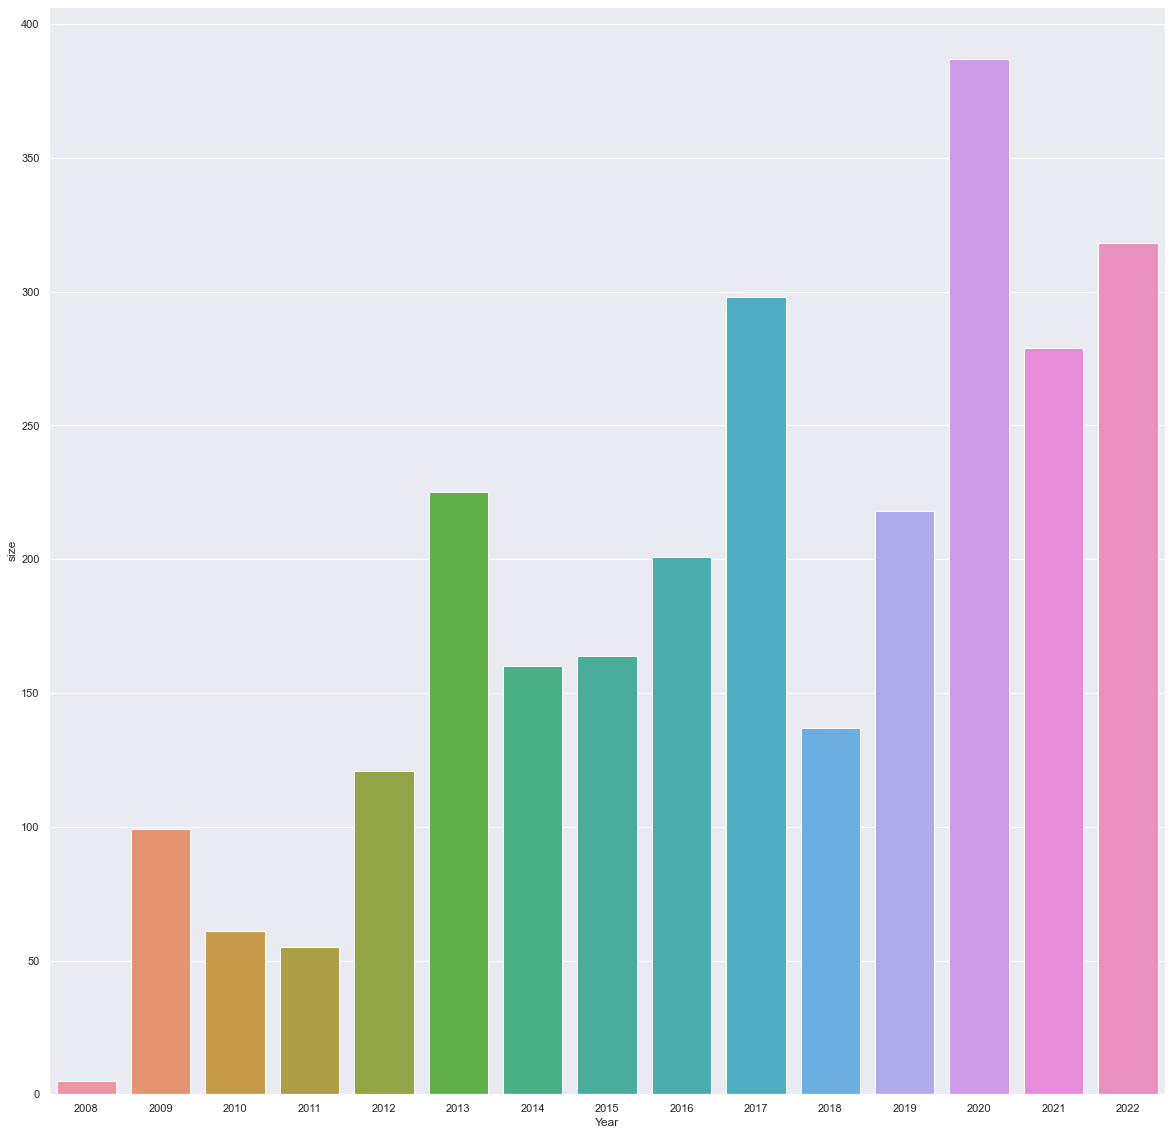

In [44]:
ax2 = sns.barplot(x="Year", y="size", data=all_video_per_year)

In [45]:
all_video_data["Category_name"] = all_video_data["Category"].map(vc_map)
all_video_data.drop(["Category"], axis=1)

,Channel_name,Title,Description,Published_date,Duration,Tags,Views,Likes,Favourites,Comments,Month,Year,Category_name
0,HKUST,HKUST Named Professorships | Otto Poon Profess...,[ #HKUST Named Professorships | Otto Poon Prof...,2022-10-13,135,[HKUST],56,0,0,0,Oct,2022,Education
1,HKUST,HKUST Named Professorships | Padma Harilela As...,[ #HKUST Named Professorships | Padma Harilela...,2022-10-11,130,[HKUST],69,1,0,0,Oct,2022,Education
2,HKUST,HKUST Entrepreneurship Fund (“E-Fund”) - Trans...,[ Innovation & Entrepreneurship | Transferring...,2022-10-11,294,[HKUST],64,1,0,0,Oct,2022,Education
3,HKUST,HKUST Named Professorships | Hari Harilela Ass...,[ #HKUST Named Professorships | Hari Harilela ...,2022-10-09,130,[HKUST],107,3,0,0,Oct,2022,Education
4,HKUST,HKUST Named Professorships | Kerry Holdings Pr...,[ #HKUST Named Professorships | Kerry Holdings...,2022-10-06,135,[HKUST],111,2,0,0,Oct,2022,Education
...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,The Hong Kong Polytechnic University,"Sharing of PolyU Outstanding Students (FAST, F...","In this video, outstanding students from Facul...",2008-09-26,378,"[PolyU, engineering, textiles, social, science...",2148,0,0,0,Sep,2008,Education
655,The Hong Kong Polytechnic University,"Sharing of PolyU Outstanding Students (FB, FCL...","In this video, outstanding students from Facu...",2008-09-26,324,"[PolyU, outstanding, student, business, constr...",1926,0,0,0,Sep,2008,Education
656,The Hong Kong Polytechnic University,PolyU Engineering Summer Camp 2008,PolyU Engineering Summer Camp 2008: Tour with ...,2008-09-25,635,"[PolyU, Engineering, summer, camp, fun, educat...",1066,0,0,0,Sep,2008,Education
657,The Hong Kong Polytechnic University,PolyU Alumni Homecoming Carnival 2008,PolyU Alumni Homecoming Carnival was successfu...,2008-08-28,461,"[PolyU, alumni, family, fun, carnival, homecom...",284,0,0,0,Aug,2008,Education


In [ ]:
#Exporting channel data for visualisation

channel_data.to_csv("University Channel Data.csv")

In [ ]:
#Exporting video specific data for visualisation

all_video_data.to_csv("YouTube University Data_Final.csv")